# 🎮 EDA: Steam Games Dataset 2025

Исследовательский анализ актуального набора данных о 90 000+ играх на Steam.  
**Источник:** Kaggle — artermiloff/steam-games-dataset 

## 🗺️ План исследования
1. Импорт библиотек и загрузка данных  
2. Первичный обзор и очистка  
3. Базовые метрики (кол-во игр, годы, цены)  
4. Визуализация релизов по годам  
5. Цены: распределение и динамика  
6. Отзывы: доля положительных vs владельцы  
7. Жанры и теги — самые популярные  
8. 💡 Итоги и ограничения

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set(rc={"figure.figsize": (12, 6)})

In [80]:
# 📥  Загрузка данных
DF_PATH = 'data/games_march2025_cleaned.csv'  
df = pd.read_csv(DF_PATH)
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [81]:

print('Строк, столбцов:', df.shape)
df.info(memory_usage='deep')
df.describe(include='all').T.head()

Строк, столбцов: (89618, 47)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appid,89618.0,NaN,NaN,NaN,1656903.958357,916838.982016,20.0,855052.5,1524730.0,2430852.5,3542350.0
name,89618,88899,Alone,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_date,89618,4459,2024-10-31,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_age,89618.0,NaN,NaN,NaN,0.183624,1.725594,-1.0,0.0,0.0,0.0,21.0
price,89618.0,NaN,NaN,NaN,7.309623,13.331073,0.0,0.99,4.99,9.99,999.98


In [82]:
# 🧹 Мини-очистка
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Столбец owners часто хранится строкой диапазона "10000-20000" — возьмём середину
def owners_mid(x):
    try:
        a, b = x.split('-')
        return (int(a) + int(b)) / 2
    except Exception:
        return pd.NA

if 'owners' in df.columns:
    df['owners_mid'] = df['owners'].astype(str).apply(owners_mid)

# Конвертируем price в float
if 'price' in df.columns:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Удаляем строки без года
df = df.dropna(subset=['release_year'])


# --- Indie-флаг ---------------------------------------------------------
import ast

def parse_tags(tag_str: str) -> list[str]:
    """
    Универсальный парсер для столбца `tags`.
    • Поддерживает формат-словарь  "{'Indie': 123, 'Action': 99}"
    • Поддерживает строку  "Indie; Action; RPG"
    Возвращает список тегов в нижнем регистре без лишних пробелов.
    """
    if pd.isna(tag_str):
        return []
    tag_str = str(tag_str)
    if tag_str.startswith('{') and tag_str.endswith('}'):
        try:
            return [t.lower() for t in ast.literal_eval(tag_str).keys()]
        except Exception:
            return []
    # строка с разделителем ";"  или ","
    return [t.strip().lower() for t in tag_str.replace(',', ';').split(';') if t.strip()]

# создаём булев столбец  is_indie
df['is_indie'] = df['tags'].apply(lambda s: 'indie' in parse_tags(s))

print("Инди-игр найдено:", df['is_indie'].sum())

Инди-игр найдено: 43408


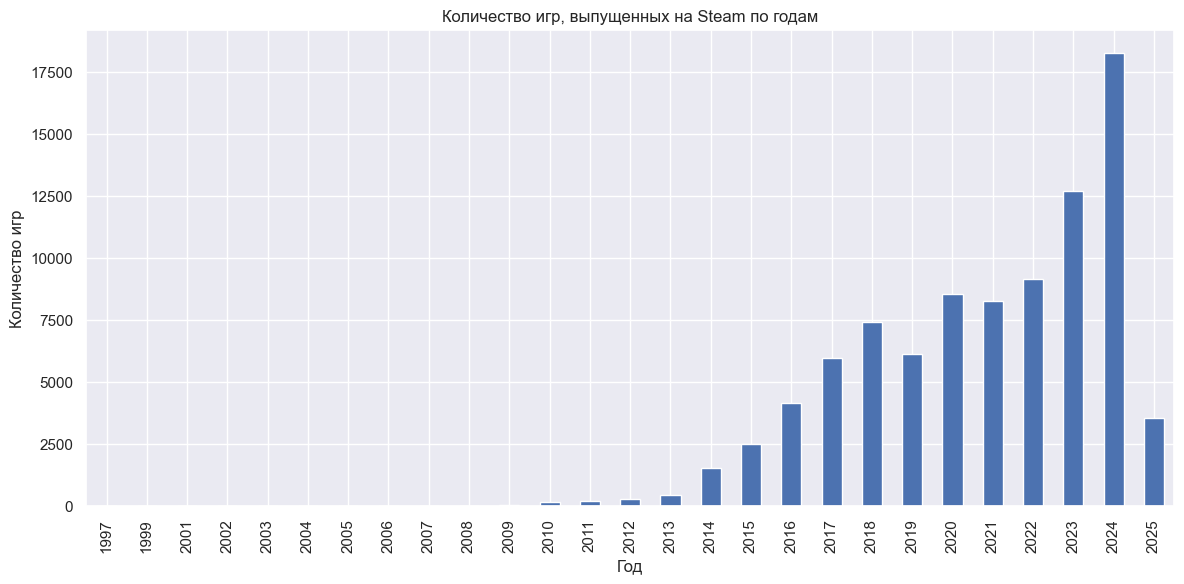

In [83]:
# 📊 Релизы по годам
games_per_year = df['release_year'].value_counts().sort_index()
games_per_year.plot(kind='bar', title='Количество игр, выпущенных на Steam по годам')
plt.ylabel('Количество игр')
plt.xlabel('Год')
plt.tight_layout()
plt.show()

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) Arial.



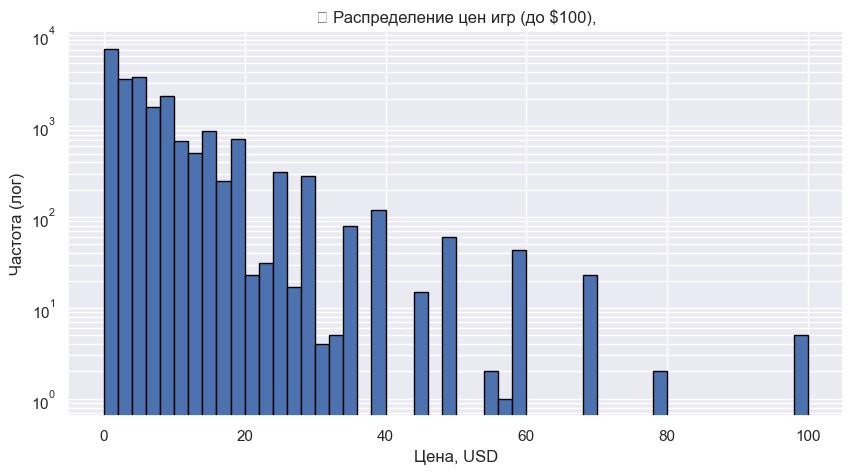

In [84]:
# 💵 Распределение цен

import numpy as np
from datetime import datetime

df_recent = df[df['release_date'] >= datetime(2024, 1, 1)].copy()
if 'price' in df_recent.columns:
    # Убираем нереалистично дорогие (например, > $100)
    prices = df_recent['price'].dropna()
    prices = prices[prices <= 100]

    # Строим логарифмическую шкалу по X
    plt.figure(figsize=(10, 5))
    # plt.hist(prices, bins=np.quantile(prices, np.linspace(0, 1, 100)),  edgecolor='black')
    plt.hist(prices, bins=np.arange(0, 101, 2), log=True, edgecolor="black")
    plt.title("💵 Распределение цен игр (до $100),")
    plt.xlabel("Цена, USD")
    plt.ylabel("Частота (лог)")
    plt.grid(True, which="both", axis="y")
    plt.show()


In [85]:
print(df.columns.tolist())



['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'developers', 'publishers', 'categories', 'genres', 'screenshots', 'movies', 'user_score', 'score_rank', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent', 'release_year', 'is_indie']


Преобразуем число владельцев в измеримые форматы данных:

In [86]:
def parse_owner_range(x):
    try:
        a, b = x.split('-')
        return (int(a) + int(b)) // 2
    except:
        return pd.NA

df['estimated_owners_mid'] = df['estimated_owners'].astype(str).apply(parse_owner_range)
df_filtered = df[
    (df['estimated_owners_mid'] > 0) &
    (df['positive'] + df['negative'] > 0)
].copy()

df_filtered['rating_ratio'] = df_filtered['positive'] / (df_filtered['positive'] + df_filtered['negative'])


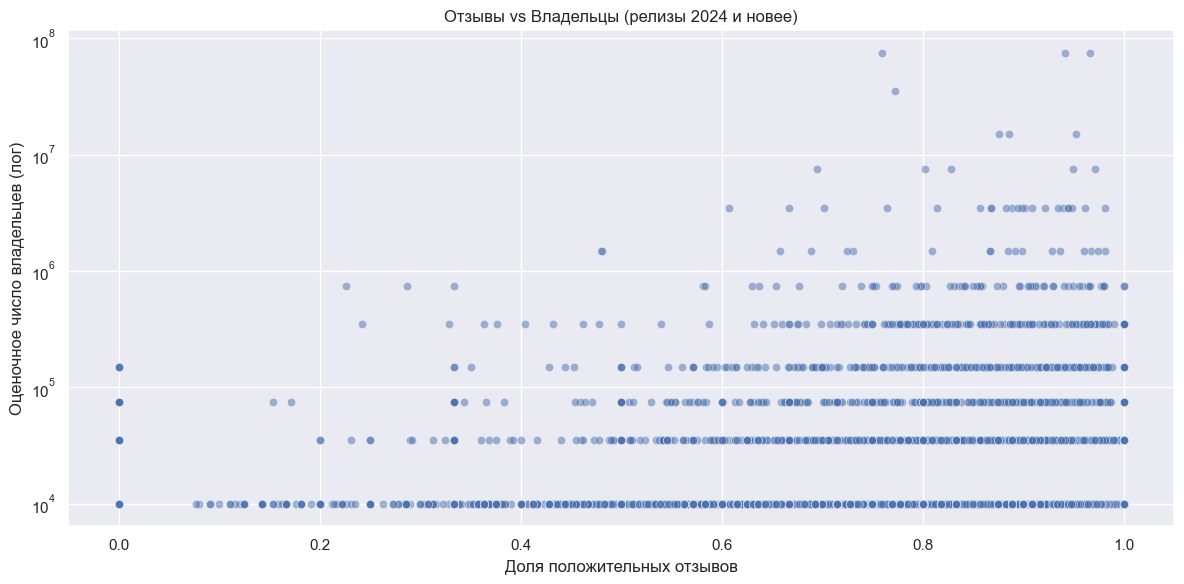

In [87]:
# %% [markdown]
# ## 🔍 Релизы 2024 + — отзывы vs владельцы

# %% 🚀 Фильтрация и подготовка
from datetime import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) оставляем игры, вышедшие после 1 янв 2024 и имеющие хотя бы один отзыв
df_recent = df[
    (df["release_date"] >= datetime(2024, 1, 1)) &
    ((df["positive"] + df["negative"]) > 0)
].copy()

# 2) переводим диапазон owners → среднее значение
def owners_mid(range_str: str):
    try:
        a, b = range_str.split("-")
        return (int(a) + int(b)) // 2
    except Exception:
        return pd.NA

df_recent["estimated_owners_mid"] = (
    df_recent["estimated_owners"]
    .astype(str)
    .apply(owners_mid)
)

# 3) убираем NaN/нулевые значения
df_recent = df_recent[
    df_recent["estimated_owners_mid"].notna() &
    (df_recent["estimated_owners_mid"] > 0)
].copy()

# 4) считаем долю положительных отзывов
df_recent["rating_ratio"] = (
    df_recent["positive"] /
    (df_recent["positive"] + df_recent["negative"])
)

# %% 📊 Визуализация
sns.scatterplot(
    data=df_recent,
    x="rating_ratio",
    y="estimated_owners_mid",
    alpha=0.5
)
plt.yscale("log")
plt.xlabel("Доля положительных отзывов")
plt.ylabel("Оценочное число владельцев (лог)")
plt.title("Отзывы vs Владельцы (релизы 2024 и новее)")
plt.grid(True)
plt.tight_layout()
plt.show()


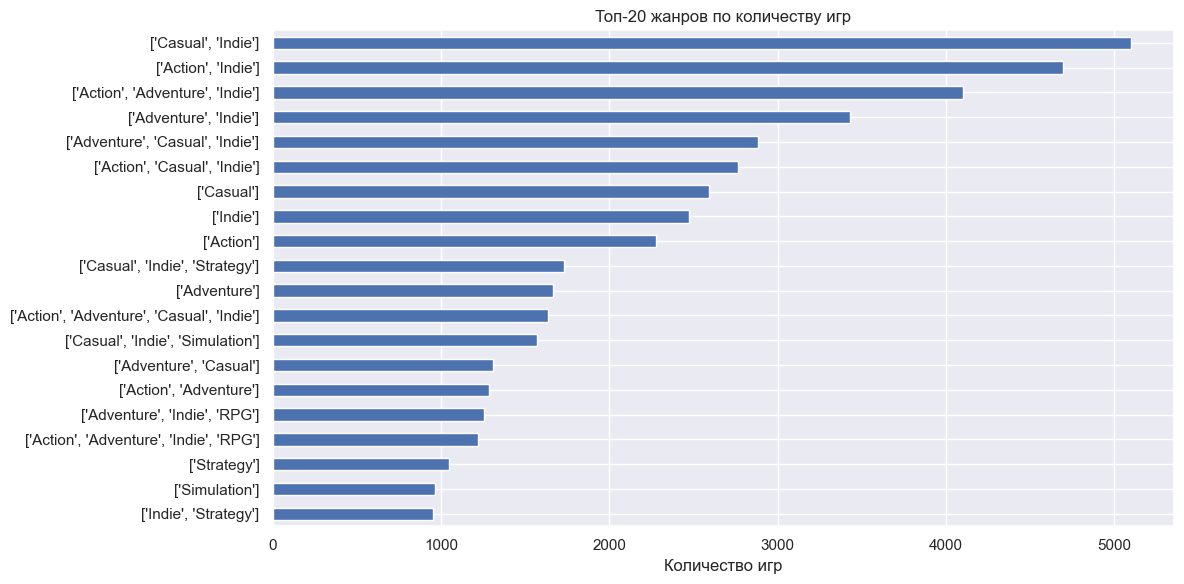

In [88]:
# 🏷️ Топ-20 жанров/тегов
if 'genres' in df.columns:
    from collections import Counter
    c = Counter()
    df['genres'].dropna().apply(lambda x: c.update([g.strip() for g in x.split(';')]))
    top_genres = pd.Series(dict(c)).sort_values(ascending=False).head(20)
    top_genres.plot(kind='barh', title='Топ-20 жанров по количеству игр')
    plt.gca().invert_yaxis()
    plt.xlabel('Количество игр')
    plt.tight_layout()
    plt.show()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\3443676396.py:44: UserWarning:

Glyph 127918 (\N{VIDEO GAME}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 127918 (\N{VIDEO GAME}) missing from font(s) Arial.



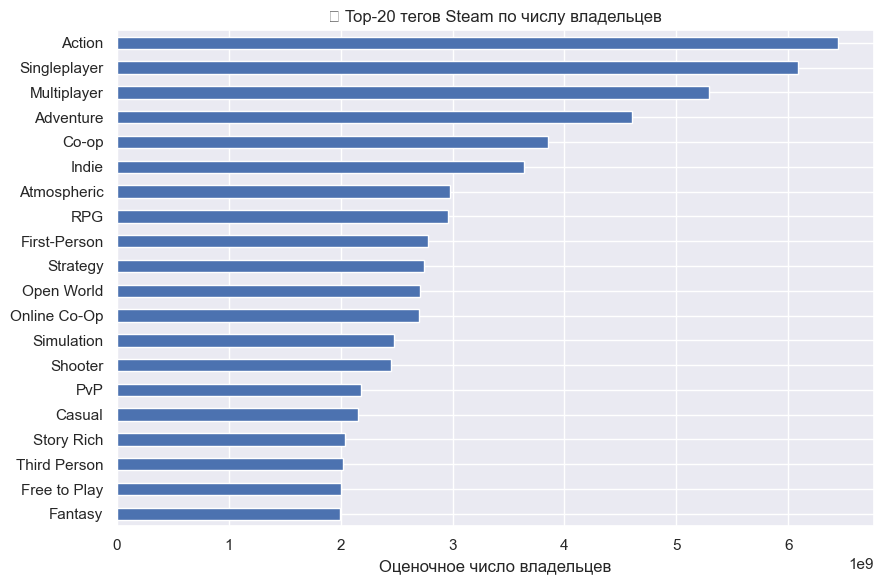

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\3443676396.py:55: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.



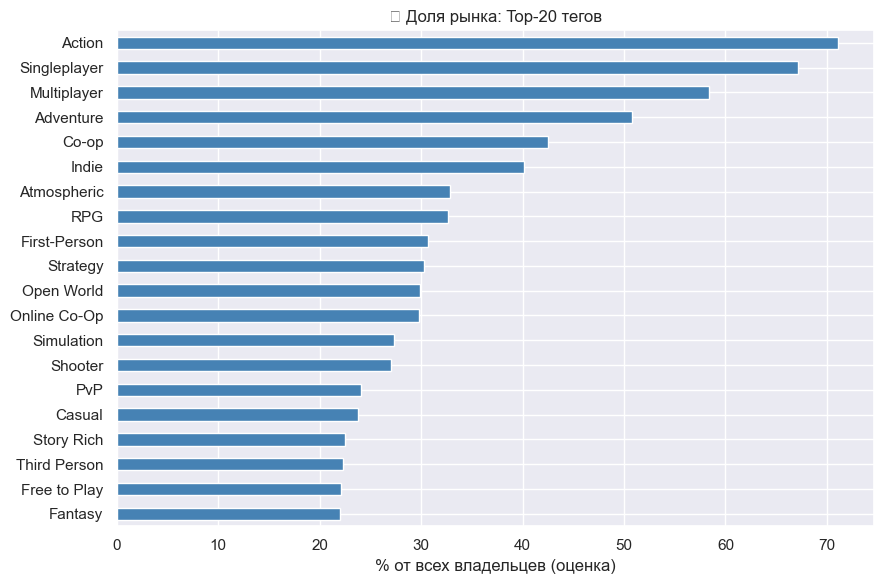

,owners_est,market_share_%
Action,6442540000,71.082998
Singleplayer,6084325000,67.130676
Multiplayer,5286800000,58.331278
Adventure,4605615000,50.815505
Co-op,3849300000,42.470793
Indie,3641155000,40.174250
Atmospheric,2980365000,32.883502
RPG,2958405000,32.641209
First-Person,2780330000,30.676440
Strategy,2740610000,30.238194


In [89]:
# %% 🏷️ Top-20 тегов по владельцам
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def owners_mid(range_str: str):
    """Середина диапазона владельцев"""
    try:
        a, b = range_str.split('-')
        return (int(a) + int(b)) // 2
    except Exception:
        return pd.NA

# 1. Убедимся, что есть численный owners_mid
if 'estimated_owners_mid' not in df.columns:
    df['estimated_owners_mid'] = df['estimated_owners'].astype(str).apply(owners_mid)

# 2. Копия датафрейма с нужными столбцами и без NaN
df_tags = df[['tags', 'estimated_owners_mid']].dropna().copy()

# 3. Парсим строку-словарь → список тегов
def parse_tags(tag_str):
    try:
        tag_dict = ast.literal_eval(tag_str)       # превращаем строку в dict
        return list(tag_dict.keys())               # нужны только названия тегов
    except Exception:
        return []

# 4. Суммируем владельцев по тегам
counter = Counter()
for tags, owners in df_tags.itertuples(index=False):
    for tag in parse_tags(tags):
        counter[tag] += owners

# 5. Top-20
top20_tags = pd.Series(counter).sort_values(ascending=False).head(20)

# 6. График
plt.figure(figsize=(9,6))
top20_tags.sort_values().plot(kind='barh')
plt.xlabel('Оценочное число владельцев')
plt.title('🎮 Top-20 тегов Steam по числу владельцев')
plt.tight_layout()
plt.show()

# %% 📊 «Доля рынка» этих тегов
total_owners = df['estimated_owners_mid'].sum()
market_share = (top20_tags / total_owners * 100).sort_values()

plt.figure(figsize=(9,6))
market_share.plot(kind='barh', color='steelblue')
plt.xlabel('% от всех владельцев (оценка)')
plt.title('📈 Доля рынка: Top-20 тегов')
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        'owners_est': top20_tags,
        'market_share_%': market_share
    }).sort_values('owners_est', ascending=False)
)



C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\3875703677.py:42: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.



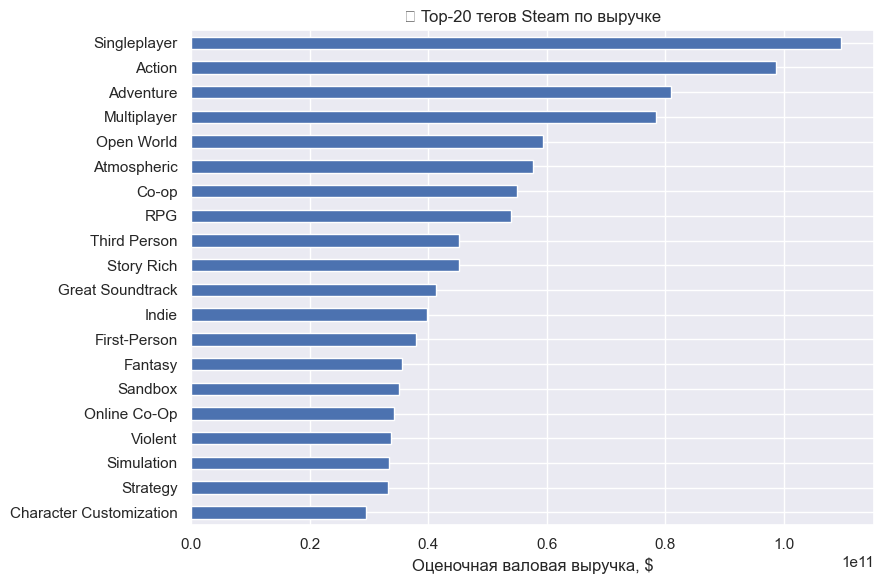

In [90]:
# %%  Top-20 тегов по валовой выручке
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# --- подготовка owners_mid и price ---
def owners_mid(range_str):
    try:
        a, b = range_str.split('-')
        return (int(a) + int(b)) // 2
    except Exception:
        return pd.NA

if 'estimated_owners_mid' not in df.columns:
    df['estimated_owners_mid'] = df['estimated_owners'].astype(str).apply(owners_mid)

df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0)

# --- оценка выручки игры ---
df['revenue_est'] = df['price'] * df['estimated_owners_mid']

# --- агрегация по тегам ---
def parse_tags(tag_str):
    try:
        return list(ast.literal_eval(tag_str).keys())
    except Exception:
        return []

rev_counter = Counter()
for tags, revenue in df[['tags', 'revenue_est']].dropna().itertuples(index=False):
    for tag in parse_tags(tags):
        rev_counter[tag] += revenue

top20_rev = pd.Series(rev_counter).sort_values(ascending=False).head(20)

# --- визуализация ---
plt.figure(figsize=(9,6))
top20_rev.sort_values().plot(kind='barh')
plt.xlabel('Оценочная валовая выручка, $')
plt.title('💰 Top-20 тегов Steam по выручке')
plt.tight_layout()
plt.show()


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\2012424733.py:47: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.



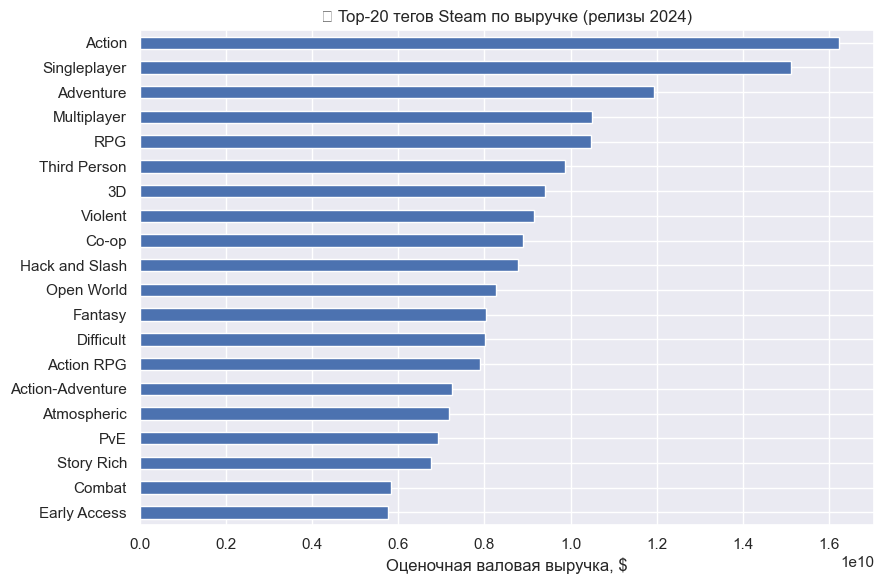

In [91]:
# %% 💰 Top-20 тегов по выручке (2024)
import ast, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

# ── 0. Фильтр по году ──────────────────────────────────────────────────────────
df_2024 = df[
    (df['release_date'] >= datetime(2024, 1, 1)) &
    (df['release_date'] <  datetime(2025, 1, 1))
].copy()

# ── 1. Подготовка численных столбцов ──────────────────────────────────────────
def owners_mid(rng):
    try:
        a, b = rng.split('-')
        return (int(a) + int(b)) // 2
    except Exception:
        return pd.NA

if 'estimated_owners_mid' not in df_2024.columns:
    df_2024['estimated_owners_mid'] = (
        df_2024['estimated_owners'].astype(str).apply(owners_mid)
    )

df_2024['price'] = pd.to_numeric(df_2024['price'], errors='coerce').fillna(0)
df_2024['revenue_est'] = df_2024['price'] * df_2024['estimated_owners_mid']

# ── 2. Агрегация выручки по тегам ─────────────────────────────────────────────
def tag_list(tag_str):
    try:
        return list(ast.literal_eval(tag_str).keys())
    except Exception:
        return []

rev_counter = Counter()
for tags, rev in df_2024[['tags', 'revenue_est']].dropna().itertuples(index=False):
    for tag in tag_list(tags):
        rev_counter[tag] += rev

top20_rev24 = pd.Series(rev_counter).sort_values(ascending=False).head(20)

# ── 3. Визуализация ───────────────────────────────────────────────────────────
plt.figure(figsize=(9,6))
top20_rev24.sort_values().plot(kind='barh')
plt.xlabel('Оценочная валовая выручка, $')
plt.title('💰 Top-20 тегов Steam по выручке (релизы 2024)')
plt.tight_layout()
plt.show()


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\2361571886.py:9: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.



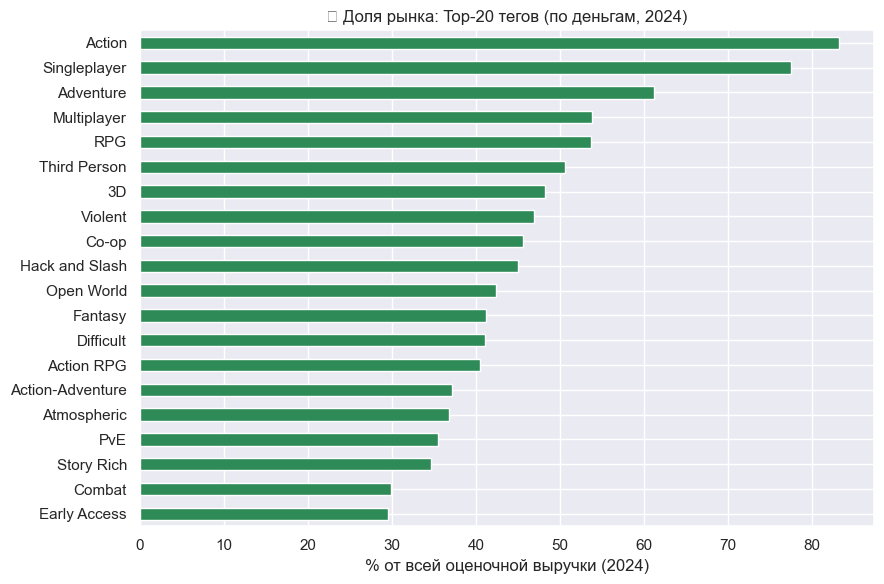

,revenue_est_$,market_share_%
Action,16239097200,83.26
Singleplayer,15131729050,77.58
Adventure,11934940600,61.19
Multiplayer,10494340550,53.81
RPG,10474872100,53.71
Third Person,9865494800,50.58
3D,9417455050,48.29
Violent,9144022650,46.88
Co-op,8906486100,45.67
Hack and Slash,8770508700,44.97


In [92]:
# %% 📈 Доля рынка по выручке (2024)
total_rev_2024 = df_2024['revenue_est'].sum()
share_rev24 = (top20_rev24 / total_rev_2024 * 100).sort_values()

plt.figure(figsize=(9,6))
share_rev24.plot(kind='barh', color='seagreen')
plt.xlabel('% от всей оценочной выручки (2024)')
plt.title('📊 Доля рынка: Top-20 тегов (по деньгам, 2024)')
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        'revenue_est_$': top20_rev24.round(0).astype(int),
        'market_share_%': share_rev24.round(2)
    }).sort_values('revenue_est_$', ascending=False)
)

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\3109988471.py:62: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.



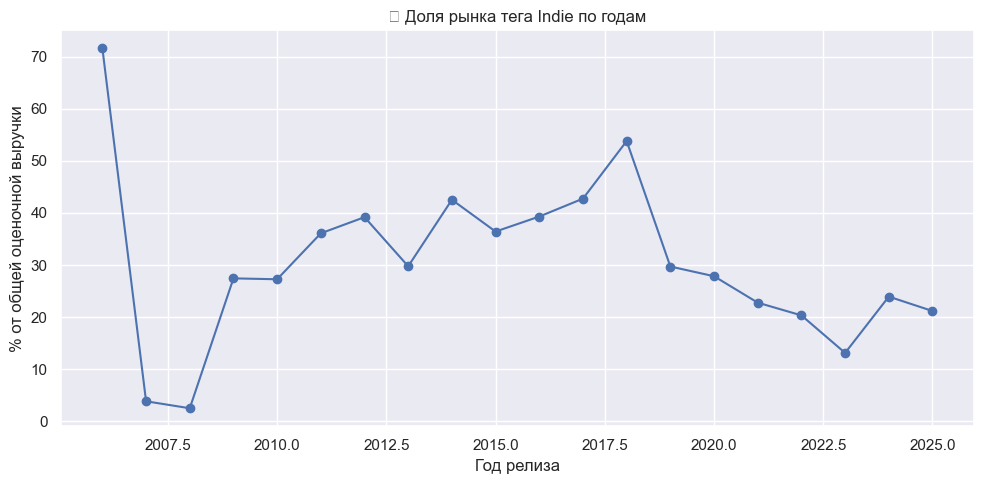

,indie_market_share_%
release_year,
2025,21.19
2024,23.94
2023,13.15
2022,20.34
2021,22.78
2020,27.86
2019,29.72
2018,53.79
2017,42.74


In [93]:
# %% 📊 Доля «рынка» для тега *Indie* по годам
import ast, pandas as pd, matplotlib.pyplot as plt

# ── 0. Убедимся, что есть release_year, estimated_owners_mid и revenue_est ──
if 'release_year' not in df.columns:
    df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

def owners_mid(r):
    try:
        a, b = r.split('-')
        return (int(a) + int(b)) // 2
    except Exception:
        return pd.NA

if 'estimated_owners_mid' not in df.columns:
    df['estimated_owners_mid'] = df['estimated_owners'].astype(str).apply(owners_mid)

df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0)
df['revenue_est'] = df['price'] * df['estimated_owners_mid']

# ── 1. Функция для извлечения списка тегов ───────────────────────────────────
def tag_list(tag_str: str):
    try:
        return list(ast.literal_eval(tag_str).keys())
    except Exception:
        return []

# ── 2. Флаг: является ли игра «Indie» ────────────────────────────────────────
df['is_indie'] = df['tags'].apply(lambda s: 'Indie' in tag_list(s))

year_stats = (
    df.groupby('release_year')
      .agg(revenue_year=('revenue_est', 'sum'),
           games_year   =('appid', 'count'))
)

valid_years = year_stats[
    (year_stats['revenue_year'] >= 1_000_0) &
    (year_stats['games_year']   >= 5)
].index

rev_total = (
    df[df['release_year'].isin(valid_years)]
      .groupby('release_year')['revenue_est'].sum()
)

rev_indie = (
    df[df['is_indie'] & df['release_year'].isin(valid_years)]
      .groupby('release_year')['revenue_est'].sum()
)

share_indie = (rev_indie / rev_total * 100).sort_index()


# ── 4. График доли «Indie» по годам ──────────────────────────────────────────
plt.figure(figsize=(10,5))
share_indie.sort_index().plot(marker='o')
plt.ylabel('% от общей оценочной выручки')
plt.xlabel('Год релиза')
plt.title('📈 Доля рынка тегa Indie по годам')
plt.grid(True)
plt.tight_layout()
plt.show()

# ── 5. Табличный вид для отчёта ──────────────────────────────────────────────
display(
    share_indie.round(2).to_frame('indie_market_share_%')
      .sort_index(ascending=False)
      .head(15)   # последние 15 лет
)


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_18244\2207614299.py:16: UserWarning:

Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) Arial.

c:\Users\Пользователь\Desktop\python_from_otus\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) Arial.



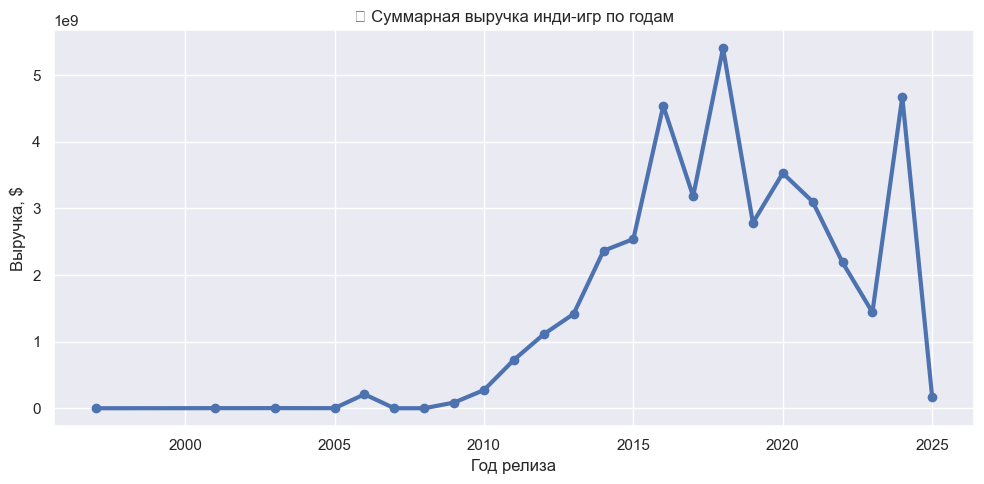

,revenue_est_$
release_year,
2025,167233050
2024,4670097400
2023,1440021650
2022,2188721700
2021,3099945000
2020,3527970500
2019,2784127400
2018,5400160000
2017,3181281200


In [94]:
# %% 📊 Валовая выручка инди-игр по годам
df_indie = df[df['is_indie'] & df['release_year'].notna()].copy()

rev_by_year = (
    df_indie.groupby('release_year')['revenue_est']
            .sum()
            .sort_index()
)

plt.figure(figsize=(10,5))
rev_by_year.plot(linewidth=3, marker='o')
plt.title('💸 Суммарная выручка инди-игр по годам')
plt.ylabel('Выручка, $')
plt.xlabel('Год релиза')
plt.grid(True)
plt.tight_layout()
plt.show()

# Можно вывести таблицу
display(
    rev_by_year.round(0).astype(int).to_frame('revenue_est_$')
              .sort_index(ascending=False)
              .head(15)
)


In [95]:
import nbformat
import plotly
print("nbformat:", nbformat.__version__)
print("plotly:", plotly.__version__)


nbformat: 5.10.4
plotly: 6.2.0


In [96]:
import ast

def parse_tags(tag_str):
    try:
        return list(ast.literal_eval(tag_str).keys())
    except Exception:
        return []

# Флаг: является ли игра инди
df['is_indie'] = df['tags'].apply(lambda s: 'Indie' in parse_tags(s))


In [97]:
# Должно вывести True
print({'release_year','estimated_owners_mid','revenue_est','is_indie','tags'}.issubset(df.columns))


True


In [98]:
# %% 🎯 Интерактивный график: выручка инди-игр по годам
import plotly.express as px
import pandas as pd

# 1. Отбираем только инди-игры с валидными годами и выручкой
df_indie_plot = df[df['is_indie']].copy()
df_indie_plot = df_indie_plot[
    df_indie_plot['release_year'].notna() &
    df_indie_plot['revenue_est'].notna() &
    df_indie_plot['revenue_est'].apply(lambda x: isinstance(x, (int, float))) &
    (df_indie_plot['revenue_est'] > 0)
]

# 2. Ограничим годами (по желанию)
df_indie_plot = df_indie_plot[df_indie_plot['release_year'] >= 2010]

# 3. Строим интерактивный scatter
fig = px.scatter(
    df_indie_plot,
    x='release_year',
    y='revenue_est',
    hover_data={
        'name': True,
        'release_year': True,
        'revenue_est': ':.0f',
    },
    labels={
        'release_year': 'Год релиза',
        'revenue_est': 'Выручка, $',
        'name': 'Название игры'
    },
    title='🎯 Инди-игры: выручка по годам (интерактив)'
)

fig.update_traces(marker=dict(size=6, opacity=0.4))
fig.update_yaxes(type='log')
fig.update_layout(height=600)

fig.show()


In [100]:
# %% 🎯 Интерактивный график: выручка инди-игр по месяцам с 2024
import plotly.express as px
import pandas as pd

# 1. Отбираем только инди-игры с валидными годами и выручкой
df_indie_plot = df[df['is_indie']].copy()
df_indie_plot = df_indie_plot[
    df_indie_plot['release_year'].notna() &
    df_indie_plot['revenue_est'].notna() &
    df_indie_plot['revenue_est'].apply(lambda x: isinstance(x, (int, float))) &
    (df_indie_plot['revenue_est'] > 0)
]

# 2. Ограничим годами (по желанию)
df_indie_plot = df_indie_plot[df_indie_plot['release_year'] >= 2024]

# 3. Строим интерактивный scatter
fig = px.scatter(
    df_indie_plot,
    x='release_date',
    y='revenue_est',
    hover_data={
        'name': True,
        'release_date': True,
        'revenue_est': ':.0f',
    },
    labels={
        'release_date': 'Дата релиза',
        'revenue_est': 'Выручка, $',
        'name': 'Название игры'
    },
    title='🎯 Инди-игры: выручка по датам выхода (интерактив)'
)

fig.update_traces(marker=dict(size=6, opacity=0.4))
fig.update_yaxes(type='log')
fig.update_layout(height=600)

fig.show()
